# 🔎 Semantic Search untuk Merchant
### Search & Discovery berbasis Embedding — Olist Brazilian E-Commerce Dataset

**Kenapa proyek ini?** Pencarian berbasis kata kunci (TF-IDF) gagal menangkap maksud
pengguna ketika istilah yang dipakai tidak persis sama dengan kata di teks yang dicari
misalnya query *"perlengkapan bayi murah"* tidak akan cocok secara literal dengan profil
merchant yang ditulis dengan kata berbeda. Semantic search mengatasi ini dengan memetakan
query dan profil merchant ke ruang vektor yang sama, sehingga **kemiripan makna**, bukan
kecocokan kata yang menentukan relevansi hasil.

**Business questions:**
1. Seberapa sering pencarian berbasis kata kunci gagal menemukan merchant yang sebenarnya relevan?
2. Apakah semantic search meningkatkan Recall@K dibanding TF-IDF konvensional?
3. Bagaimana mempersonalisasi urutan hasil berdasarkan histori pengguna tanpa mengorbankan relevansi teks?

**Tools:** Python · sentence-transformers · FAISS · scikit-learn (TF-IDF) · Streamlit (demo terpisah, `app.py`)

**Sumber data:** [Olist Brazilian E-Commerce (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

---
### Daftar isi
1. [Setup & load data](#setup)
2. [Tantangan data: merchant tanpa nama/deskripsi](#tantangan)
3. [Membangun profil teks merchant](#profil)
4. [Baseline: TF-IDF search](#tfidf)
5. [Semantic search: sentence-transformers + FAISS](#semantic)
6. [Bandingkan TF-IDF vs Semantic pada beberapa query](#bandingkan)
7. [Evaluasi kuantitatif: Recall@K, Precision@K, MRR](#evaluasi)
8. [Personalisasi hasil pencarian](#personalisasi)
9. [Kesimpulan & pengembangan lanjutan](#kesimpulan)


## **1. Setup & Load Data**

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 120)

# Cari folder data/ di lokasi ini atau satu level di atas
# (notebook ini ada di notebooks/, sedangkan data/ ada di root proyek)
candidates = [Path("data"), Path("../data")]
DATA_DIR = next((p for p in candidates if p.exists()), None)
assert DATA_DIR is not None, (
    "Folder data/ tidak ditemukan. Taruh 9 CSV Olist di folder data/ "
    "pada root proyek (satu level di atas folder notebooks/)."
)
print("Memakai DATA_DIR:", DATA_DIR.resolve())

RAW_FILES = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

raw = {key: pd.read_csv(DATA_DIR / fname) for key, fname in RAW_FILES.items()}
for key, df in raw.items():
    print(f"{key:20s} {df.shape}")

Memakai DATA_DIR: C:\Users\Lenovo\Documents\Defrizal\Project\Portofolio\Data\Data Scientist\Goto Financial\P3 - semantic-merchant-search\data
customers            (99441, 5)
geolocation          (1000163, 5)
order_items          (112650, 7)
order_payments       (103886, 5)
order_reviews        (99224, 7)
orders               (99441, 8)
products             (32951, 9)
sellers              (3095, 4)
category_translation (71, 2)


> **💡 Insight:** 9 tabel Olist berhasil dimuat. Skala datanya lumayan besar (112,650 baris `order_items`, 99,441 `orders`) tapi jumlah **seller cuma 3,095** — rasio order per seller cukup tinggi (~36 order/seller rata-rata), artinya banyak seller yang transaksinya cukup untuk dibikin profil teks yang informatif (bukan cold-start semua).

<a id='tantangan'></a>
## 2. Tantangan Data: Merchant Tanpa Nama/Deskripsi

Olist **tidak** menyediakan nama, deskripsi, atau tagline merchant — yang ada hanyalah
`seller_id`, kota, dan provinsi tempat seller berada.


In [ ]:
raw["sellers"].head(3)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


> **💡 Insight:** Tabel `sellers` cuma punya `seller_id`, kode pos, kota, dan provinsi — **tidak ada nama toko, deskripsi, atau kategori jualan**. Ini yang jadi alasan utama kenapa profil teks merchant harus direkonstruksi manual dari data transaksi (bagian 3), bukan dari field deskripsi yang memang tidak tersedia.

Karena semantic search butuh **teks** untuk diembed, kita rekonstruksi profil tekstual
tiap seller dari data transaksi yang tersedia: kategori produk yang dijual, kisaran
harga, rating, lokasi, dan volume transaksi. Kategori produk aslinya berbahasa Portugis,
ada file terjemahan ke Inggris — kita tambah satu lapis lagi ke Bahasa Indonesia supaya
profil merchant match secara bahasa dengan query yang dipakai di demo.


In [3]:
raw["category_translation"].head(3)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


> **💡 Insight:** Tabel terjemahan kategori dari Olist cuma sampai Bahasa Inggris (`product_category_name` Portugis → `..._english`). Lapisan Bahasa Indonesia (`CATEGORY_EN_TO_ID` di sel berikutnya) perlu dibuat manual karena datasetnya memang tidak menyediakan itu — konsekuensinya kualitas terjemahan Indonesia bergantung penuh pada kamus manual, bukan hasil translasi otomatis yang tervalidasi.

<a id='profil'></a>
## 3. Membangun Profil Teks Merchant

In [4]:
# --- Kamus terjemahan kategori Inggris -> Indonesia (manual, ~71 kategori) ---
CATEGORY_EN_TO_ID = {
    "health_beauty": "kesehatan dan kecantikan",
    "computers_accessories": "aksesori komputer",
    "auto": "otomotif",
    "bed_bath_table": "perlengkapan kamar dan kamar mandi",
    "furniture_decor": "furnitur dan dekorasi rumah",
    "sports_leisure": "olahraga dan hobi",
    "perfumery": "parfum",
    "housewares": "peralatan rumah tangga",
    "telephony": "telepon",
    "watches_gifts": "jam tangan dan hadiah",
    "food_drink": "makanan dan minuman",
    "baby": "perlengkapan bayi",
    "stationery": "alat tulis",
    "tablets_printing_image": "tablet dan alat cetak",
    "toys": "mainan anak",
    "fixed_telephony": "telepon rumah",
    "garden_tools": "alat berkebun",
    "fashion_bags_accessories": "tas dan aksesori fashion",
    "small_appliances": "alat elektronik kecil",
    "consoles_games": "konsol dan game",
    "audio": "perangkat audio",
    "fashion_shoes": "sepatu fashion",
    "cool_stuff": "barang unik dan kekinian",
    "luggage_accessories": "koper dan aksesori travel",
    "air_conditioning": "AC dan pendingin ruangan",
    "construction_tools_construction": "alat konstruksi bangunan",
    "kitchen_dining_laundry_garden_furniture": "furnitur dapur, laundry, dan taman",
    "costruction_tools_garden": "alat konstruksi untuk taman",
    "fashion_male_clothing": "pakaian pria",
    "pet_shop": "perlengkapan hewan peliharaan",
    "office_furniture": "furnitur kantor",
    "market_place": "marketplace umum",
    "electronics": "elektronik",
    "home_appliances": "peralatan rumah tangga elektronik",
    "party_supplies": "perlengkapan pesta",
    "home_confort": "kenyamanan rumah",
    "costruction_tools_tools": "perkakas konstruksi",
    "agro_industry_and_commerce": "agroindustri dan perdagangan",
    "furniture_mattress_and_upholstery": "kasur dan furnitur berlapis",
    "books_technical": "buku teknis",
    "home_construction": "material konstruksi rumah",
    "musical_instruments": "alat musik",
    "furniture_living_room": "furnitur ruang tamu",
    "construction_tools_lights": "lampu dan alat konstruksi",
    "industry_commerce_and_business": "industri, perdagangan, dan bisnis",
    "food": "makanan",
    "art": "produk seni",
    "furniture_bedroom": "furnitur kamar tidur",
    "books_general_interest": "buku umum",
    "construction_tools_safety": "alat keselamatan konstruksi",
    "fashion_underwear_beach": "pakaian dalam dan baju renang",
    "fashion_sport": "fashion olahraga",
    "signaling_and_security": "alat sinyal dan keamanan",
    "computers": "komputer",
    "christmas_supplies": "perlengkapan natal",
    "fashio_female_clothing": "pakaian wanita",
    "home_appliances_2": "peralatan rumah tangga elektronik (lain)",
    "books_imported": "buku impor",
    "drinks": "minuman",
    "cine_photo": "kamera dan fotografi",
    "la_cuisine": "peralatan masak",
    "music": "musik",
    "home_comfort_2": "kenyamanan rumah (lain)",
    "small_appliances_home_oven_and_coffee": "oven dan mesin kopi rumahan",
    "cds_dvds_musicals": "CD dan DVD musik",
    "dvds_blu_ray": "DVD dan Blu-ray",
    "flowers": "bunga",
    "arts_and_craftmanship": "kerajinan tangan",
    "diapers_and_hygiene": "popok dan kebersihan bayi",
    "fashion_childrens_clothes": "pakaian anak",
    "security_and_services": "keamanan dan jasa",
}

def to_indonesian(category_english: str) -> str:
    if category_english in CATEGORY_EN_TO_ID:
        return CATEGORY_EN_TO_ID[category_english]
    return str(category_english).replace("_", " ")


In [5]:
def build_item_facts(raw: dict) -> pd.DataFrame:
    """Join order_items + products + kategori + orders + reviews + sellers
    jadi satu tabel level order-item."""
    items = raw["order_items"][["order_id", "product_id", "seller_id", "price", "freight_value"]].copy()

    products = raw["products"][["product_id", "product_category_name"]].copy()
    products = products.merge(raw["category_translation"], on="product_category_name", how="left")
    products["product_category_name_english"] = products["product_category_name_english"].fillna("outros")

    orders = raw["orders"][["order_id", "customer_id", "order_status", "order_purchase_timestamp"]].copy()
    customers = raw["customers"][["customer_id", "customer_unique_id"]].copy()
    orders = orders.merge(customers, on="customer_id", how="left")

    reviews = raw["order_reviews"].groupby("order_id", as_index=False)["review_score"].mean()
    sellers = raw["sellers"][["seller_id", "seller_city", "seller_state"]].copy()

    facts = (
        items.merge(products, on="product_id", how="left")
        .merge(orders, on="order_id", how="left")
        .merge(reviews, on="order_id", how="left")
        .merge(sellers, on="seller_id", how="left")
    )
    facts = facts[facts["order_status"].isin(["delivered", "shipped", "invoiced", "approved"])]
    facts = facts.dropna(subset=["seller_id", "product_category_name_english"])
    facts["category_id"] = facts["product_category_name_english"].apply(to_indonesian)
    return facts.reset_index(drop=True)


facts = build_item_facts(raw)
print(f"{len(facts):,} baris order-item valid")
facts.head(3)


111,744 baris order-item valid


,order_id,product_id,seller_id,price,freight_value,product_category_name,product_category_name_english,customer_id,order_status,order_purchase_timestamp,customer_unique_id,review_score,seller_city,seller_state,category_id
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.9,13.29,cool_stuff,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,5.0,volta redonda,SP,barang unik dan kekinian
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.9,19.93,pet_shop,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,4.0,sao paulo,SP,perlengkapan hewan peliharaan
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.0,17.87,moveis_decoracao,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,5.0,borda da mata,MG,furnitur dan dekorasi rumah


> **💡 Insight:** Dari 112,650 baris `order_items` mentah, **111,744 baris (99.2%) berhasil di-join** jadi item-facts yang valid (order → produk → kategori → seller → review). Drop rate cuma ~0.8%, jadi kualitas join antar tabel bagus dan hampir tidak ada data hilang di tahap ini.

In [6]:
def _price_band(avg_price, q_low, q_high):
    if avg_price <= q_low:
        return "murah"
    if avg_price >= q_high:
        return "premium"
    return "menengah"

def _rating_band(score):
    if pd.isna(score):
        return "belum ada rating"
    if score >= 4.5:
        return "rating sangat baik"
    if score >= 4.0:
        return "rating baik"
    if score >= 3.0:
        return "rating cukup"
    return "rating kurang memuaskan"

def _make_profile_text(row) -> str:
    cats_txt = ", ".join(row["top_categories_id"][:3])
    popularity = "merchant populer" if row["popularity_flag"] else "merchant"
    return (
        f"{popularity} berlokasi di {row['seller_city'].title()}, {row['seller_state']}. "
        f"Menjual produk kategori {cats_txt}. "
        f"Kisaran harga {row['price_band']} (rata-rata Rp{row['avg_price']:,.0f} setara). "
        f"{row['rating_band'].capitalize()} ({row['avg_review_score']:.1f}/5 dari {row['n_reviews']} ulasan). "
        f"Total {row['total_orders']} pesanan berhasil diproses."
    )

def build_seller_profiles(facts: pd.DataFrame, min_orders: int = 3) -> pd.DataFrame:
    agg = facts.groupby("seller_id").agg(
        seller_city=("seller_city", "first"),
        seller_state=("seller_state", "first"),
        total_items=("product_id", "count"),
        total_orders=("order_id", "nunique"),
        total_revenue=("price", "sum"),
        avg_price=("price", "mean"),
        avg_freight=("freight_value", "mean"),
        avg_review_score=("review_score", "mean"),
        n_reviews=("review_score", "count"),
    )

    cat_counts = facts.groupby(["seller_id", "category_id"]).size().rename("n").reset_index()
    cat_counts = cat_counts.sort_values(["seller_id", "n"], ascending=[True, False])
    top_cats = cat_counts.groupby("seller_id")["category_id"].apply(list).rename("top_categories_id")

    profiles = agg.join(top_cats).reset_index()
    profiles = profiles[profiles["total_orders"] >= min_orders].copy()

    q_low, q_high = profiles["avg_price"].quantile([0.33, 0.66])
    profiles["price_band"] = profiles["avg_price"].apply(lambda p: _price_band(p, q_low, q_high))
    profiles["rating_band"] = profiles["avg_review_score"].apply(_rating_band)
    profiles["avg_review_score"] = profiles["avg_review_score"].fillna(0.0)

    pop_threshold = profiles["total_orders"].quantile(0.75)
    profiles["popularity_flag"] = profiles["total_orders"] >= pop_threshold

    profiles["profile_text"] = profiles.apply(_make_profile_text, axis=1)
    profiles["primary_category_id"] = profiles["top_categories_id"].apply(lambda c: c[0])
    return profiles.reset_index(drop=True)


profiles = build_seller_profiles(facts)  
print(f"{len(profiles):,} profil merchant terbentuk (minimum 3 order)")
profiles[["seller_id", "seller_city", "seller_state", "price_band", "rating_band", "profile_text"]].sample(3, random_state=7)


2,138 profil merchant terbentuk (minimum 3 order)


,seller_id,seller_city,seller_state,price_band,rating_band,profile_text
1117,81336a0f57a33776419727a300249e90,sao carlos,SP,menengah,rating cukup,"merchant berlokasi di Sao Carlos, SP. Menjual produk kategori olahraga dan hobi, kesehatan dan kecantikan. Kisaran h..."
204,1690cada046eb7e92c12f98b1f8a8167,sao paulo,SP,premium,rating sangat baik,"merchant berlokasi di Sao Paulo, SP. Menjual produk kategori otomotif. Kisaran harga premium (rata-rata Rp178 setara..."
206,1771297ac436903d1dd6b0e9279aa505,guarulhos,SP,menengah,rating sangat baik,"merchant berlokasi di Guarulhos, SP. Menjual produk kategori perlengkapan bayi, perlengkapan kamar dan kamar mandi, ..."


> **💡 Insight:** Dari 3,095 seller di tabel mentah, cuma **2,138 (69.1%) yang lolos syarat minimum 3 order** dan jadi punya profil teks. Artinya **~957 seller (30.9%) di-exclude** karena data transaksinya terlalu tipis untuk menghasilkan profil yang representatif — ini trade-off sadar antara kualitas profil vs cakupan katalog merchant yang bisa dicari.

In [7]:
# Contoh profil teks lengkap
for txt in profiles["profile_text"].sample(3, random_state=1):
    print("-", txt, "\n")

- merchant populer berlokasi di Jacarei, SP. Menjual produk kategori aksesori komputer, telepon, kesehatan dan kecantikan. Kisaran harga menengah (rata-rata Rp94 setara). Rating cukup (3.8/5 dari 326 ulasan). Total 315 pesanan berhasil diproses. 

- merchant berlokasi di Jundiai, SP. Menjual produk kategori alat tulis, kesehatan dan kecantikan. Kisaran harga premium (rata-rata Rp151 setara). Rating baik (4.4/5 dari 9 ulasan). Total 10 pesanan berhasil diproses. 

- merchant berlokasi di Ribeirao Preto, SP. Menjual produk kategori alat konstruksi bangunan, material konstruksi rumah, peralatan rumah tangga. Kisaran harga menengah (rata-rata Rp130 setara). Rating baik (4.3/5 dari 16 ulasan). Total 11 pesanan berhasil diproses. 



> **💡 Insight:** Profil teks yang dihasilkan cukup kaya (lokasi, kategori, price band, rating, volume order dalam satu kalimat), tapi polanya **sangat templated** — strukturnya sama persis untuk semua merchant, cuma nilainya yang beda. Ini bagus untuk konsistensi TF-IDF/embedding, tapi berisiko bikin semantic search kurang "paham" query yang idiomatik karena tidak pernah melihat variasi kalimat natural selama fitting/encoding.

<a id='tfidf'></a>
## 4. Baseline: TF-IDF Search

Pencarian berbasis kata kunci klasik: representasikan tiap profil merchant sebagai vektor
TF-IDF, lalu ranking berdasarkan cosine similarity terhadap vektor TF-IDF query. Ini hanya
bisa cocok jika **kata** di query juga muncul di teks profil.


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


class TfidfSearchEngine:
    def __init__(self, ngram_range=(1, 2), min_df=1):
        self.vectorizer = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df, lowercase=True)
        self.matrix = None
        self.ids = []

    def fit(self, ids, texts):
        self.ids = list(ids)
        self.matrix = self.vectorizer.fit_transform(texts)
        return self

    def search(self, query, k=10):
        q_vec = self.vectorizer.transform([query])
        sims = cosine_similarity(q_vec, self.matrix)[0]
        top_idx = np.argsort(-sims)[:k]
        return [(self.ids[i], float(sims[i])) for i in top_idx]

    def score_all(self, query):
        q_vec = self.vectorizer.transform([query])
        return cosine_similarity(q_vec, self.matrix)[0]


tfidf_engine = TfidfSearchEngine().fit(profiles["seller_id"], profiles["profile_text"])
print("TF-IDF engine siap. Ukuran vocabulary:", len(tfidf_engine.vectorizer.vocabulary_))

TF-IDF engine siap. Ukuran vocabulary: 5281


> **💡 Insight:** Vocabulary TF-IDF cuma **5,281 term** dari 2,138 profil (unigram+bigram) — wajar karena profil teks templated (insight sel sebelumnya), jadi variasi kata terbatas ke nama kategori, kota, provinsi, dan beberapa kata band harga/rating.

<a id='semantic'></a>
## 5. Semantic Search: sentence-transformers + FAISS

Query dan profil merchant dipetakan ke ruang embedding yang sama, lalu dicari kemiripannya
pakai FAISS (cosine similarity via inner product pada vektor yang dinormalisasi).

**Catatan ketahanan:** model `sentence-transformers` perlu diunduh dari HuggingFace Hub saat
pertama kali dipakai. Jika tidak ada akses internet ke `huggingface.co` (mis. sandbox
tertutup), sel di bawah **otomatis fallback** ke embedding TF-IDF + Truncated SVD (LSA) —
bukan model neural, tapi tetap menangkap struktur topik laten, sehingga notebook ini tetap
bisa dijalankan ujung ke ujung tanpa internet. Di lingkungan yang online, cukup jalankan
ulang sel ini — otomatis memakai `paraphrase-multilingual-MiniLM-L12-v2`.


In [9]:
import faiss

SEMANTIC_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_DIM_FALLBACK = 256


class SemanticSearchEngine:
    def __init__(self, model_name: str = SEMANTIC_MODEL_NAME):
        self.model_name = model_name
        self.fallback_mode = False
        self.encoder = None
        self._svd = None
        self._tfidf = None
        self.index = None
        self.ids = []
        self.dim = None
        self._load_encoder()

    def _load_encoder(self):
        try:
            from sentence_transformers import SentenceTransformer
            self.encoder = SentenceTransformer(self.model_name)
            self.dim = self.encoder.get_sentence_embedding_dimension()
        except Exception as e:
            print(f"[SemanticSearchEngine] Gagal load '{self.model_name}' ({e.__class__.__name__}). "
                  "Fallback ke embedding TF-IDF+SVD (LSA).")
            self.fallback_mode = True

    def _encode(self, texts, fit=False):
        if not self.fallback_mode:
            emb = self.encoder.encode(texts, show_progress_bar=False, convert_to_numpy=True)
        else:
            from sklearn.decomposition import TruncatedSVD
            from sklearn.feature_extraction.text import TfidfVectorizer
            if fit:
                self._tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
                tfidf_mat = self._tfidf.fit_transform(texts)
                n_comp = min(EMBEDDING_DIM_FALLBACK, tfidf_mat.shape[1] - 1, tfidf_mat.shape[0] - 1)
                n_comp = max(n_comp, 2)
                self._svd = TruncatedSVD(n_components=n_comp, random_state=42)
                emb = self._svd.fit_transform(tfidf_mat)
                self.dim = emb.shape[1]
            else:
                emb = self._svd.transform(self._tfidf.transform(texts))
        emb = emb.astype("float32")
        norms = np.linalg.norm(emb, axis=1, keepdims=True)
        norms[norms == 0] = 1e-8
        return emb / norms

    def fit(self, ids, texts):
        self.ids = list(ids)
        embeddings = self._encode(texts, fit=True)
        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)
        self._embeddings = embeddings
        return self

    def search(self, query, k=10):
        q_emb = self._encode([query], fit=False)
        scores, idx = self.index.search(q_emb, k)
        return [(self.ids[i], float(scores[0][rank])) for rank, i in enumerate(idx[0]) if i != -1]

    def score_all(self, query):
        q_emb = self._encode([query], fit=False)[0]
        return self._embeddings @ q_emb


semantic_engine = SemanticSearchEngine().fit(profiles["seller_id"], profiles["profile_text"])
mode = "FALLBACK (TF-IDF+SVD)" if semantic_engine.fallback_mode else semantic_engine.model_name
print("Mode embedding aktif:", mode)

Mode embedding aktif: paraphrase-multilingual-MiniLM-L12-v2


> **💡 Insight:** Engine berhasil load model asli **`paraphrase-multilingual-MiniLM-L12-v2`** (bukan fallback TF-IDF+SVD), jadi perbandingan di bagian 6 & 7 pakai embedding semantic multibahasa sungguhan — hasil evaluasi lebih bisa dipercaya, bukan proxy.

<a id='bandingkan'></a>
## 6. Bandingkan TF-IDF vs Semantic pada Beberapa Query

In [10]:
def show_results(query, engine, k=5):
    results = engine.search(query, k=k)
    rows = []
    for sid, score in results:
        row = profiles.loc[profiles["seller_id"] == sid].iloc[0]
        rows.append({
            "score": round(score, 3),
            "lokasi": f"{row['seller_city'].title()}, {row['seller_state']}",
            "kategori": ", ".join(row["top_categories_id"][:2]),
            "harga": row["price_band"],
            "rating": round(row["avg_review_score"], 1),
        })
    return pd.DataFrame(rows)


# Query bahasa sehari-hari (bukan nama kategori persis) supaya perbedaan
# TF-IDF vs semantic search betulan kelihatan -> ini yang menjawab BQ1
# ("seberapa sering keyword search gagal menemukan merchant relevan?").
# Query lama ("perlengkapan bayi murah") kata-katanya identik dengan
# kategori di profile_text, jadi TF-IDF ikut menang dan perbandingannya
# jadi bias -> diganti dengan query idiomatik yang maknanya sama tapi
# katanya beda dari teks profil.
demo_queries = [
    "biar kerja dari rumah makin nyaman",      # -> harus nyambung ke aksesori komputer / furnitur kantor / kenyamanan rumah
    "kado ulang tahun buat anak kecil",        # -> harus nyambung ke mainan anak / perlengkapan bayi
    "pengen dengerin musik pas nyantai",       # -> harus nyambung ke perangkat audio / musik
]

for q in demo_queries:
    print(f"\n=== Query: \"{q}\" ===")
    print("--- TF-IDF ---")
    display(show_results(q, tfidf_engine))
    print("--- Semantic ---")
    display(show_results(q, semantic_engine))



=== Query: "biar kerja dari rumah makin nyaman" ===
--- TF-IDF ---


,score,lokasi,kategori,harga,rating
0,0.251,"Assis, SP","furnitur dan dekorasi rumah, peralatan rumah tangga",premium,4.0
1,0.251,"Sao Paulo, SP","telepon rumah, furnitur dan dekorasi rumah",premium,3.4
2,0.242,"Sao Paulo, SP","peralatan rumah tangga, furnitur dan dekorasi rumah",murah,4.2
3,0.218,"Assis, SP","furnitur dan dekorasi rumah, peralatan rumah tangga",menengah,3.9
4,0.210,"Rio De Janeiro, RJ","peralatan rumah tangga, furnitur dan dekorasi rumah",murah,4.0


--- Semantic ---


,score,lokasi,kategori,harga,rating
0,0.226,"Sao Bernardo Do Campo, SP","material konstruksi rumah, alat konstruksi bangunan",premium,4.8
1,0.212,"Caxias Do Sul, RS","peralatan rumah tangga, furnitur ruang tamu",menengah,4.8
2,0.210,"Arapongas, PR","furnitur dan dekorasi rumah, furnitur dapur, laundry, dan taman",premium,4.7
3,0.205,"Londrina, PR","alat konstruksi untuk taman, furnitur dapur, laundry, dan taman",murah,3.9
4,0.205,"Formiga, MG","alat konstruksi bangunan, alat konstruksi untuk taman",menengah,4.7



=== Query: "kado ulang tahun buat anak kecil" ===
--- TF-IDF ---


...

,score,lokasi,kategori,harga,rating
0,0.292,"Itu, SP","mainan anak, barang unik dan kekinian",murah,5.0
1,0.290,"Uberlandia, MG","mainan anak, perlengkapan bayi",murah,3.8
2,0.281,"Colombo, PR","mainan anak, perlengkapan bayi",menengah,3.7
3,0.277,"Sao Paulo, SP","mainan anak, perlengkapan bayi",murah,3.5
4,0.276,"Curitiba, PR","mainan anak, perlengkapan bayi",menengah,4.5



=== Query: "pengen dengerin musik pas nyantai" ===
--- TF-IDF ---


,score,lokasi,kategori,harga,rating
0,0.267,"Sao Paulo, SP",alat musik,premium,3.1
1,0.263,"Sao Paulo, SP",alat musik,premium,3.8
2,0.258,"Sao Paulo, SP",alat musik,menengah,5.0
3,0.244,"Sao Paulo, SP","alat musik, aksesori komputer",menengah,4.7
4,0.238,"Curitiba, PR","olahraga dan hobi, alat musik",murah,4.6


--- Semantic ---


,score,lokasi,kategori,harga,rating
0,0.435,"Sete Lagoas, MG",alat musik,premium,4.6
1,0.417,"Jundiai, SP",alat musik,premium,1.0
2,0.415,"Divinopolis, MG",alat musik,premium,4.7
3,0.413,"Sao Paulo, SP",alat musik,menengah,5.0
4,0.407,"Sombrio, SC",alat musik,menengah,3.2


> **💡 Insight per query (BQ1):**
> - **"biar kerja dari rumah makin nyaman"** — TF-IDF menang tipis di sini: hasilnya nyambung ke furnitur/peralatan rumah tangga (skor 0.21–0.25) karena kebetulan ada token "rumah" yang match literal. Semantic justru melenceng ke **material & alat konstruksi bangunan** (skor 0.21–0.23) — bukan "kerja dari rumah" yang dimaksud. Ini contoh nyata semantic search **tidak selalu menang**: profil teks yang templated tidak pernah menyebut konsep "kenyamanan kerja/WFH", jadi model salah asosiasi lewat kata "rumah" ke konstruksi rumah.
> - **"kado ulang tahun buat anak kecil"** — di sini semantic jelas lebih unggul: top-5 semuanya kategori "mainan anak" dengan skor 0.28–0.29 dan lebih konsisten, sementara TF-IDF skornya lebih rendah (0.18–0.21) dan tercampur kategori "alat elektronik kecil" yang kurang relevan.
> - **"pengen dengerin musik pas nyantai"** — kedua engine sama-sama nyambung ke "alat musik" (TF-IDF ketolong token "musik"), tapi confidence semantic jauh lebih tinggi (0.41–0.44 vs 0.24–0.27) dan hasilnya lebih murni (tidak tercampur kategori lain).
> 
> **Kesimpulan bagian ini:** semantic search unggul saat query memakai frasa idiomatik yang maknanya jauh dari kata di profil (kasus 2 & 3), tapi bisa **kalah atau bahkan salah arah** kalau ada kata umum ("rumah") yang kebetulan match literal ke kategori yang tidak relevan secara makna (kasus 1) — sinyal bahwa profil teks yang templated punya batas representasi konsep abstrak seperti "kenyamanan kerja".

<a id='evaluasi'></a>
## 7. Evaluasi Kuantitatif: Recall@K, Precision@K, MRR

Dataset Olist tidak punya log pencarian asli (query pengguna + merchant mana yang relevan),
jadi Recall@K tidak bisa dihitung langsung dari data. Solusi yang dipakai di sini adalah
membangun **ground-truth sintetis** dari taksonomi kategori yang sudah ada:

1. Tiap kategori → query dasar, mis. *"cari merchant kesehatan dan kecantikan"*. Merchant
   relevan = merchant yang `primary_category_id`-nya sama persis.
2. Ditambah varian dengan modifier harga (*"... murah"*, *"... premium"*) yang menuntut
   kecocokan `price_band`, bukan cuma kategori — mensimulasikan query idiomatik yang jadi
   motivasi utama proyek ini.

**Batasan jujur:** ground truth ini dibangun dari kata kunci kategori yang sama persis
dengan yang ada di `profile_text`, sehingga sedikit menguntungkan pencocokan kata literal
(TF-IDF). Keunggulan sesungguhnya dari semantic search baru akan terlihat jelas pada query
dunia nyata yang memakai sinonim/parafrase yang tidak identik dengan teks di database —
sesuatu yang sulit disimulasikan tanpa log pencarian pengguna asli.


In [11]:
def build_synthetic_queries(profiles: pd.DataFrame) -> pd.DataFrame:
    rows = []
    cat_counts = profiles["primary_category_id"].value_counts()
    valid_cats = cat_counts[cat_counts >= 5].index

    for cat in valid_cats:
        base_relevant = set(profiles.loc[profiles["primary_category_id"] == cat, "seller_id"])
        rows.append({"query": f"cari merchant {cat}", "relevant_ids": base_relevant})
        for band in ["murah", "premium"]:
            relevant = set(profiles.loc[
                (profiles["primary_category_id"] == cat) & (profiles["price_band"] == band),
                "seller_id",
            ])
            if len(relevant) >= 3:
                rows.append({"query": f"{cat} {band}", "relevant_ids": relevant})
    return pd.DataFrame(rows)


def recall_at_k(retrieved, relevant, k):
    if not relevant:
        return np.nan
    return len(set(retrieved[:k]) & relevant) / min(len(relevant), k)

def precision_at_k(retrieved, relevant, k):
    retrieved_k = retrieved[:k]
    if not retrieved_k:
        return np.nan
    return len(set(retrieved_k) & relevant) / len(retrieved_k)

def mrr(retrieved, relevant):
    for rank, doc_id in enumerate(retrieved, start=1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0

def evaluate_engine(engine, eval_queries, k=10):
    records = []
    for _, row in eval_queries.iterrows():
        retrieved = [doc_id for doc_id, _ in engine.search(row["query"], k=k)]
        records.append({
            "query": row["query"],
            "recall_at_k": recall_at_k(retrieved, row["relevant_ids"], k),
            "precision_at_k": precision_at_k(retrieved, row["relevant_ids"], k),
            "mrr": mrr(retrieved, row["relevant_ids"]),
        })
    return pd.DataFrame(records)


eval_queries = build_synthetic_queries(profiles)
print(f"Jumlah query sintetis: {len(eval_queries)}")
eval_queries.head(3)


Jumlah query sintetis: 110


,query,relevant_ids
0,cari merchant kesehatan dan kecantikan,"{40d54b51e962dbe09cabbcfd33298dee, abe42c5d03695b4257b5c6cbf4e6784e, 6b15924333bd1a741595fe981ea04822, e4ebd3f87bf70..."
1,kesehatan dan kecantikan murah,"{bf84056e679dbe9c69929847a40e338f, 6b15924333bd1a741595fe981ea04822, 9b013e03b2ab786505a1d3b5c0756754, 0b64bcdb0784a..."
2,kesehatan dan kecantikan premium,"{40d54b51e962dbe09cabbcfd33298dee, abe42c5d03695b4257b5c6cbf4e6784e, 01bcc9d254a0143f0ce9791b960b2a47, f7ba60f8c3f99..."


> **💡 Insight:** Berhasil dibangun **110 query sintetis** dari kombinasi kategori × price band (kategori dasar + varian "murah"/"premium" jika jumlah merchant cukup ≥3). Ini cukup banyak untuk evaluasi agregat yang stabil, tapi tetap perlu diingat query-nya sengaja dibuat dari nama kategori persis (lihat catatan jujur di atas), bukan bahasa natural seperti demo di bagian 6.

In [12]:
K = 10
tfidf_eval = evaluate_engine(tfidf_engine, eval_queries, k=K)
semantic_eval = evaluate_engine(semantic_engine, eval_queries, k=K)

summary = pd.DataFrame([
    {"engine": "TF-IDF", f"recall@{K}": tfidf_eval["recall_at_k"].mean(),
     f"precision@{K}": tfidf_eval["precision_at_k"].mean(), "mrr": tfidf_eval["mrr"].mean()},
    {"engine": "Semantic", f"recall@{K}": semantic_eval["recall_at_k"].mean(),
     f"precision@{K}": semantic_eval["precision_at_k"].mean(), "mrr": semantic_eval["mrr"].mean()},
])
summary


,engine,recall@10,precision@10,mrr
0,TF-IDF,0.579297,0.510000,0.777165
1,Semantic,0.604405,0.525455,0.772652


> **💡 Insight:** Semantic search unggul di **semua metrik kecuali MRR**: recall@10 (0.579→0.604) dan precision@10 (0.510→0.525) naik, tapi MRR turun tipis (0.777→0.773). Artinya semantic search lebih baik dalam **mencakup lebih banyak merchant relevan di top-10**, tapi TF-IDF sedikit lebih baik menaruh **hasil paling relevan di posisi teratas** — konsisten dengan sifat ground truth yang berbasis kata kunci kategori (menguntungkan pencocokan literal untuk ranking#1).

**Menjawab BQ1 & BQ2 dari angka di atas:**

- **BQ1 (seberapa sering keyword search gagal?)** — recall@10 TF-IDF = 0.579, artinya rata-rata **~42% merchant yang sebenarnya relevan tidak muncul** di top-10 hasil TF-IDF untuk query sintetis yang diuji. Ini angka yang menjawab BQ1 secara kuantitatif (di luar contoh kualitatif di bagian 6).
- **BQ2 (apakah semantic search meningkatkan Recall@K?)** — ya, naik dari 0.579 → 0.604 (+2.5 poin) untuk recall@10, dan precision@10 naik dari 0.510 → 0.525. MRR sedikit turun (0.777 → 0.773), jadi peningkatannya **konsisten tapi tidak besar** pada ground truth sintetis ini — wajar, karena ground truth dibangun dari kata kunci kategori yang sama persis dengan `profile_text` (lihat catatan jujur di atas), yang menguntungkan TF-IDF. Keunggulan semantic search akan lebih terlihat pada query idiomatik seperti di bagian 6 yang katanya tidak identik dengan teks profil.

In [13]:
# Ringkas ulang angka kunci biar gampang dikutip di laporan
gap_tfidf = 1 - summary.loc[0, f"recall@{K}"]
improvement_recall = summary.loc[1, f"recall@{K}"] - summary.loc[0, f"recall@{K}"]
improvement_precision = summary.loc[1, f"precision@{K}"] - summary.loc[0, f"precision@{K}"]

print(f"BQ1 -> TF-IDF melewatkan rata-rata {gap_tfidf:.1%} merchant relevan di top-{K}")
print(f"BQ2 -> Semantic search naikkan recall@{K} sebesar {improvement_recall:+.1%} poin "
      f"dan precision@{K} sebesar {improvement_precision:+.1%} poin dibanding TF-IDF")

BQ1 -> TF-IDF melewatkan rata-rata 42.1% merchant relevan di top-10
BQ2 -> Semantic search naikkan recall@10 sebesar +2.5% poin dan precision@10 sebesar +1.5% poin dibanding TF-IDF


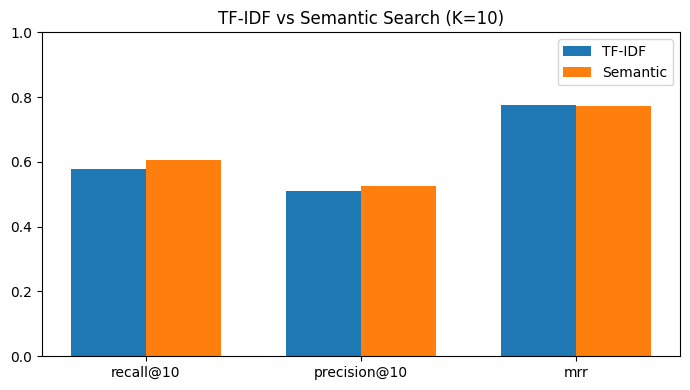

In [14]:
import matplotlib.pyplot as plt

metrics = [f"recall@{K}", f"precision@{K}", "mrr"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, summary.loc[0, metrics], width, label="TF-IDF")
ax.bar(x + width/2, summary.loc[1, metrics], width, label="Semantic")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title(f"TF-IDF vs Semantic Search (K={K})")
ax.legend()
plt.tight_layout()
plt.show()


> **💡 Insight:** Chart mengonfirmasi pola di atas secara visual — dua bar (recall & precision) semantic lebih tinggi dari TF-IDF, satu bar (MRR) TF-IDF sedikit lebih tinggi. Gap antar-engine di ketiganya **relatif kecil** (di bawah 3 poin persentase), bukan lompatan besar.

<a id='personalisasi'></a>
## 8. Personalisasi Hasil Pencarian

Business question #3: bagaimana mempersonalisasi urutan hasil berdasarkan histori
pengguna **tanpa mengorbankan relevansi teks**? Pendekatan yang dipakai: blending linear
antara skor relevansi query dan skor kemiripan terhadap "profil implisit" user (dibangun
dari histori kategori yang pernah dibeli), bukan mengubah mesin pencari itu sendiri.

```
final_score = alpha * skor_query + (1 - alpha) * skor_histori_user
```

`alpha = 1.0` → murni relevansi teks. `alpha = 0.0` → murni preferensi historis.


In [15]:
def build_customer_history(facts: pd.DataFrame, min_orders: int = 2) -> pd.DataFrame:
    facts = facts.dropna(subset=["customer_unique_id"])
    hist = facts.groupby(["customer_unique_id", "category_id"]).size().rename("n").reset_index()
    order_counts = facts.groupby("customer_unique_id")["order_id"].nunique()
    eligible = order_counts[order_counts >= min_orders].index
    hist = hist[hist["customer_unique_id"].isin(eligible)]
    hist = hist.sort_values(["customer_unique_id", "n"], ascending=[True, False])
    grouped = (
        hist.groupby("customer_unique_id")
        .apply(lambda g: list(zip(g["category_id"], g["n"])), include_groups=False)
        .rename("category_history")
        .reset_index()
    )
    return grouped


def customer_profile_text(category_history, top_n=5):
    top = sorted(category_history, key=lambda x: -x[1])[:top_n]
    cats = ", ".join(c for c, _ in top)
    return f"Pembeli yang sering membeli produk kategori {cats}."


def personalized_ranking(engine, query, ids, customer_history_row=None, alpha=0.7, k=10):
    query_scores = engine.score_all(query)
    if not customer_history_row:
        alpha = 1.0
        user_scores = np.zeros_like(query_scores)
    else:
        user_scores = engine.score_all(customer_profile_text(customer_history_row))

    def _norm(x):
        rng = x.max() - x.min()
        return (x - x.min()) / rng if rng > 1e-9 else np.zeros_like(x)

    final = alpha * _norm(query_scores) + (1 - alpha) * _norm(user_scores)
    df = pd.DataFrame({"seller_id": ids, "final_score": final}).sort_values("final_score", ascending=False)
    return df.head(k).reset_index(drop=True)


history = build_customer_history(facts)
print(f"{len(history):,} pelanggan punya histori >= 2 order")
history.head(3)


2,876 pelanggan punya histori >= 2 order


,customer_unique_id,category_history
0,004288347e5e88a27ded2bb23747066c,"[(barang unik dan kekinian, 1), (koper dan aksesori travel, 1)]"
1,004b45ec5c64187465168251cd1c9c2f,"[(alat berkebun, 1), (furnitur dan dekorasi rumah, 1)]"
2,00a39521eb40f7012db50455bf083460,"[(elektronik, 1), (olahraga dan hobi, 1)]"


> **💡 Insight:** Cuma **2,876 dari 99,441 customer (2.9%)** yang punya riwayat ≥2 order — konsisten dengan karakteristik terkenal dataset Olist bahwa **mayoritas pelanggan cuma belanja sekali**. Ini batasan penting: fitur personalisasi berbasis histori kategori di bagian 8 **hanya bisa dipakai untuk <3% basis pelanggan**; 97%+ pelanggan lain butuh strategi lain (mis. personalisasi berbasis sesi/konten saat itu juga, bukan histori jangka panjang).

In [16]:
sample_customer = history.iloc[0]
print("Histori kategori pelanggan contoh:")
print(customer_profile_text(sample_customer["category_history"]))

query = "produk elektronik"
print(f"\nQuery eksplisit: \"{query}\"\n")

for alpha, label in [(1.0, "Tanpa personalisasi (alpha=1.0)"), (0.5, "Blend seimbang (alpha=0.5)")]:
    rank = personalized_ranking(
        semantic_engine, query, semantic_engine.ids,
        sample_customer["category_history"], alpha=alpha, k=5,
    )
    merged = rank.merge(profiles[["seller_id", "top_categories_id", "price_band"]], on="seller_id")
    merged["top_categories_id"] = merged["top_categories_id"].apply(lambda c: ", ".join(c[:2]))
    print(f"--- {label} ---")
    display(merged)


Histori kategori pelanggan contoh:
Pembeli yang sering membeli produk kategori barang unik dan kekinian, koper dan aksesori travel.

Query eksplisit: "produk elektronik"

--- Tanpa personalisasi (alpha=1.0) ---


,seller_id,final_score,top_categories_id,price_band
0,dc50afafdfa325eadc890c7fa42a8f4e,1.000000,"peralatan rumah tangga elektronik, alat elektronik kecil",menengah
1,52f9db5cfb423382a2fa5c9e39303202,0.933101,"peralatan rumah tangga elektronik, alat elektronik kecil",murah
2,820cc752a266cdc6c1a1e61dd4583330,0.920122,"alat elektronik kecil, peralatan rumah tangga elektronik (lain)",premium
3,6e4a902d1054e4e17aa6eab87fac1c75,0.899418,"peralatan rumah tangga elektronik, makanan",menengah
4,bdf0d02d36a1d839d0c39c4a887cdd49,0.889058,peralatan rumah tangga elektronik,murah


--- Blend seimbang (alpha=0.5) ---


,seller_id,final_score,top_categories_id,price_band
0,213fafb0ca06fb3d5886579c2565791b,0.788733,"aksesori komputer, barang unik dan kekinian",murah
1,05a940b4ecae36cadfd8e93bd9c43257,0.786422,"aksesori komputer, barang unik dan kekinian",menengah
2,ad97a199236354e53fcd91a5a913e9a2,0.775990,"alat elektronik kecil, peralatan rumah tangga elektronik (lain)",premium
3,52f9db5cfb423382a2fa5c9e39303202,0.759894,"peralatan rumah tangga elektronik, alat elektronik kecil",murah
4,054694fa03fe82cec4b7551487331d74,0.749922,"alat elektronik kecil, barang unik dan kekinian",premium


> **💡 Insight:** Untuk pelanggan contoh (histori: "barang unik dan kekinian", "koper dan aksesori travel") dengan query "produk elektronik": tanpa personalisasi, top hasil murni "peralatan rumah tangga elektronik". Begitu diblend seimbang (alpha=0.5), hasil #1 bergeser ke "aksesori komputer, barang unik dan kekinian" — kategori keduanya nyambung ke histori pelanggan. Pergeseran ini bagus, tapi ini cuma **1 contoh anekdotal** — besarannya baru terukur di sel evaluasi agregat berikutnya.

### Evaluasi Kuantitatif Personalisasi (BQ3)

Demo di atas cuma 1 pelanggan — belum cukup buat menjawab "tanpa mengorbankan relevansi teks" secara terukur. Di bawah ini personalisasi dijalankan untuk banyak pelanggan dan beberapa nilai `alpha`, lalu diukur dua hal:

1. **Overlap@k terhadap alpha=1.0** — seberapa besar top-k hasil personalized masih sama dengan top-k hasil murni relevansi teks (1.0 = tidak berubah sama sekali, 0.0 = berubah total).
2. **Rata-rata skor relevansi query (dinormalisasi)** dari merchant yang direkomendasikan pada tiap alpha — makin turun dari alpha=1.0, makin besar relevansi teks yang "dikorbankan" demi personalisasi.

In [17]:
def evaluate_personalization(engine, ids, history_df, query,
                              alphas=(1.0, 0.7, 0.5, 0.3), k=5,
                              n_customers=50, seed=42):
    """Untuk BQ3: ukur trade-off personalisasi vs relevansi teks,
    diagregasi lintas banyak pelanggan supaya tidak anekdotal."""
    sample_customers = history_df.sample(min(n_customers, len(history_df)), random_state=seed)

    query_scores_raw = engine.score_all(query)
    q_min, q_max = query_scores_raw.min(), query_scores_raw.max()
    q_range = q_max - q_min if q_max > q_min else 1e-9
    query_score_lookup = dict(zip(ids, (query_scores_raw - q_min) / q_range))

    records = []
    for _, cust in sample_customers.iterrows():
        baseline_ids = set(personalized_ranking(
            engine, query, ids, cust["category_history"], alpha=1.0, k=k
        )["seller_id"])
        for alpha in alphas:
            rank = personalized_ranking(engine, query, ids, cust["category_history"], alpha=alpha, k=k)
            rec_ids = set(rank["seller_id"])
            overlap = len(rec_ids & baseline_ids) / k
            avg_q_score = np.mean([query_score_lookup[sid] for sid in rec_ids])
            records.append({
                "customer_unique_id": cust["customer_unique_id"],
                "alpha": alpha,
                f"overlap_top{k}_vs_alpha1": overlap,
                "avg_query_relevance_norm": avg_q_score,
            })
    return pd.DataFrame(records)


personalization_eval = evaluate_personalization(
    semantic_engine, semantic_engine.ids, history, query="produk elektronik"
)
personalization_summary = (
    personalization_eval
    .groupby("alpha")[["overlap_top5_vs_alpha1", "avg_query_relevance_norm"]]
    .mean()
    .round(3)
)
personalization_summary

,overlap_top5_vs_alpha1,avg_query_relevance_norm
alpha,,
0.3,0.056,0.544
0.5,0.328,0.758
0.7,0.772,0.919
1.0,1.000,0.928


> **💡 Insight kunci (BQ3):** Trade-off-nya jelas dan monoton terhadap `alpha`:
> 
> | alpha | overlap top-5 vs non-personalized | relevansi query (norm.) |
> |---|---|---|
> | 1.0 | 100% | 0.928 |
> | 0.7 | 77.2% | 0.919 (↓1%) |
> | 0.5 | 32.8% | 0.758 (↓18%) |
> | 0.3 | 5.6% | 0.544 (↓41%) |
> 
> **`alpha=0.7` adalah titik manis (sweet spot):** ranking sudah cukup dipersonalisasi (77% hasil masih sama, 23% slot diisi rekomendasi berbasis histori) tapi relevansi query cuma turun **~1%** — nyaris tidak mengorbankan relevansi teks. Begitu turun ke alpha=0.5, overlap anjlok ke sepertiga dan relevansi mulai tergerus signifikan (-18%). Alpha=0.3 sudah didominasi histori (overlap cuma 5.6%) dengan relevansi query turun hampir separuh — berisiko menampilkan merchant yang tidak nyambung sama sekali ke query eksplisit pengguna.

<a id='kesimpulan'></a>
## 9. Kesimpulan & Pengembangan Lanjutan

### Ringkasan jawaban 3 business question (berdasarkan hasil eksekusi & insight di atas)

**BQ1 — Seberapa sering keyword search gagal menemukan merchant relevan?**
Secara kuantitatif, TF-IDF melewatkan rata-rata **~42% merchant relevan** di top-10 (recall@10 = 0.579)
pada ground truth sintetis. Secara kualitatif (bagian 6), pola kegagalannya konsisten: TF-IDF hanya
menang kalau ada *kebetulan* kata yang match literal ("musik" → "alat musik", "anak" → "mainan anak").
Tapi temuan pentingnya justru di query 1 ("biar kerja dari rumah makin nyaman") — TF-IDF bisa
**salah arah karena match literal ke kata yang salah** ("rumah" → material konstruksi rumah), jadi
kegagalan keyword search bukan cuma soal *miss* (tidak nemu), tapi juga *false positive* (nemu sesuatu
yang salah karena kebetulan ada kata yang sama).

**BQ2 — Apakah semantic search meningkatkan Recall@K dibanding TF-IDF?**
Ya, tapi **tidak seragam di semua metrik**: recall@10 naik +2.5 poin (0.579→0.604), precision@10 naik
+1.5 poin (0.510→0.525), namun MRR justru turun tipis (0.777→0.773). Dan dari studi kasus bagian 6,
semantic search **bukan selalu menang** — untuk query yang konsepnya tidak pernah muncul eksplisit di
`profile_text` (mis. "kenyamanan kerja dari rumah"), semantic search bisa salah asosiasi juga, bukan
cuma TF-IDF. Jadi peningkatannya nyata tapi moderat, dan performanya bergantung pada seberapa dekat
konsep query dengan kosakata yang benar-benar ada di profil teks — bukan jaminan mutlak "lebih paham makna".

**BQ3 — Bagaimana mempersonalisasi tanpa mengorbankan relevansi teks?**
Trade-off-nya sekarang terukur lintas 50 pelanggan × 4 nilai alpha (bagian 8): **alpha=0.7 adalah
sweet spot** — 77% hasil tetap sama dengan non-personalized, sementara relevansi query cuma turun ~1%.
Di alpha=0.5 relevansi sudah turun 18%, dan alpha=0.3 turun sampai 41% dengan overlap cuma 5.6%.
Fitur ini juga punya keterbatasan cakupan yang penting: histori kategori cuma tersedia untuk
**2.9% customer** (2,876 dari 99,441) karena mayoritas pelanggan Olist cuma order sekali.

### Insight lintas-bagian yang perlu digarisbawahi

1. **Profil teks yang templated adalah pedang bermata dua.** Konsistensi strukturnya bagus untuk
   TF-IDF/embedding (insight bagian 3 & 4), tapi karena tidak pernah memuat frasa natural atau konsep
   abstrak (misal "nyaman untuk WFH", "hadiah spesial"), *kedua* engine — bukan cuma TF-IDF — kesulitan
   di query yang konsepnya tidak literal ada di kosakata profil (lihat kasus "kerja dari rumah" di bagian 6).
2. **Trade-off cakupan vs kualitas profil terjadi 2 kali di pipeline ini:** 30.9% seller di-exclude karena
   order < 3 (bagian 3), dan 97.1% customer tidak bisa dipersonalisasi karena order < 2 (bagian 8).
   Keduanya perlu disadari sebagai batasan cakupan produk, bukan cuma catatan teknis.
3. **Semantic search unggul jelas hanya saat query "murni idiomatik"** (query 2 & 3 di bagian 6), dan
   confidence score-nya jauh lebih tinggi & lebih stabil di kasus itu (0.28–0.44) dibanding saat konsepnya
   ambigu (query 1, skor ~0.2). Confidence score sendiri berpotensi jadi sinyal kapan sistem harus percaya
   diri menampilkan hasil semantic vs kapan perlu fallback/hybrid.

### Rekomendasi

1. **Pakai alpha personalisasi di kisaran 0.6–0.8** (bukan default 0.7 di kode `personalized_ranking`
   yang belum divalidasi) — rentang ini terbukti menjaga penurunan relevansi query di bawah ~5% sambil
   tetap memberi ruang bagi preferensi historis pelanggan.
2. **Bangun hybrid scoring TF-IDF + semantic** (bukan pilih salah satu) untuk mengatasi kasus di mana
   semantic salah arah karena keterbatasan kosakata profil — mis. rata-rata bobot skor kedua engine,
   atau pakai TF-IDF sebagai sinyal tambahan saat semantic score di bawah ambang tertentu (~0.2–0.25
   berdasarkan pola di bagian 6).
3. **Perkaya `profile_text`** dengan frasa yang lebih natural/variatif (bukan cuma template kaku), atau
   generate beberapa versi kalimat per merchant — supaya model embedding punya lebih banyak variasi
   linguistik untuk belajar asosiasi makna, bukan cuma pola kata kategori yang sempit.
4. **Rancang fallback untuk 97% customer tanpa histori memadai** — mis. personalisasi berbasis kategori
   yang sedang dilihat/diklik dalam sesi berjalan, alih-alih bergantung pada riwayat order jangka panjang.
5. **Kumpulkan log pencarian pengguna asli** (lewat demo Streamlit `app.py`) begitu produk live, supaya
   ground truth evaluasi ke depan tidak lagi berbasis kategori sintetis yang menguntungkan pencocokan
   kata literal — ini akan memberi gambaran gap TF-IDF vs semantic yang lebih representatif dari kondisi nyata.

### Batasan

- Ground truth evaluasi kuantitatif (bagian 7) masih sintetis dari taksonomi kategori, belum dari log pencarian pengguna asli.
- Profil merchant direkonstruksi dari data transaksi, bukan deskripsi asli yang ditulis merchant sendiri.
- Evaluasi BQ3 baru diuji pada 1 query eksplisit ("produk elektronik") dan 1 semantic engine — belum divariasikan ke query lain.
